# Portfolio Replication — Full Comparison
Each section calls a single function from `utils/`. All outputs (figures, pickles) are saved automatically.

**Run order:** Data Loader → Linear Models → Kalman → NN → Evaluate

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pickle, logging
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils import setup_logging
setup_logging(logging.INFO)

PICKLE_DIR = ROOT / 'results' / 'data' / 'picklefiles'

## 1 · Data Loader
Loads prices, computes weekly returns, constructs the **monster index** (50% HFRX, 25% MSCI World, 25% Global Agg Bond), and saves 5 diagnostic plots.

In [2]:
from utils.data_loader import run_data_loader

data = run_data_loader(
    filepath=ROOT / 'data' / 'Dataset3_PortfolioReplicaStrategy.xlsx'
)

19:01:41 | INFO     | utils.data_loader         — ============================================================
19:01:41 | INFO     | utils.data_loader         — DATA LOADER — START
19:01:41 | INFO     | utils.data_loader         — ============================================================
19:01:41 | INFO     | utils.data_loader         — Reading Excel file: /Users/simonezani/Documents/github/fintech-group-work/BusinessCase3/data/Dataset3_PortfolioReplicaStrategy.xlsx (sheet=0)
19:01:41 | INFO     | utils.data_loader         — Loaded 705 observations | 2007-10-23 → 2021-04-20
19:01:41 | INFO     | utils.data_loader         — Computing weekly returns from price levels
19:01:41 | INFO     | utils.data_loader         — Returns shape: (704, 15)
19:01:41 | INFO     | utils.data_loader         — Monster index composition: HFRXGL Index=50% | MXWO Index=25% | LEGATRUU Index=25%
19:01:41 | INFO     | utils.data_loader         — X shape: (704, 11) | y shape: (704,)
19:01:41 | INFO     | utils.d

In [3]:
print('Prices  :', data['prices'].shape,  '|', data['prices'].index[0].date(), '→', data['prices'].index[-1].date())
print('Returns :', data['returns'].shape)
print('X       :', data['X'].shape,  '(futures features)')
print('y       :', data['y'].shape,  '(monster index)')
data['y'].describe().round(5)

Prices  : (705, 15) | 2007-10-23 → 2021-04-20
Returns : (704, 15)
X       : (704, 11) (futures features)
y       : (704,) (monster index)


count    704.00000
mean       0.00049
std        0.00878
min       -0.06694
25%       -0.00361
50%        0.00143
75%        0.00552
max        0.03377
Name: MonsterIndex, dtype: float64

## 2 · Linear Models
Five estimators on a shared rolling walk-forward loop.
Hyperparameters selected by TimeSeriesSplit CV on training data only.

| Model | Penalty | Notes |
|---|---|---|
| OLS | none | unconstrained baseline |
| Ridge | L2 | uniform shrinkage |
| LASSO | L1 | sparse, interpretable |
| ElasticNet | L1+L2 | combined |
| WOLS | — | exponential decay weights, λ selected by TE-minimising CV |

In [4]:
from utils.run_linear_models import run_linear_models

linear_data = run_linear_models(
    X=data['X'],
    y=data['y'],
    train_end_date='2018-12-31',
    window=52,
)

19:01:42 | INFO     | utils.run_linear_models   — ============================================================
19:01:42 | INFO     | utils.run_linear_models   — LINEAR MODELS — START
19:01:42 | INFO     | utils.run_linear_models   — ============================================================
19:01:42 | INFO     | utils.run_linear_models   — Train: 583 obs (2007-10-30 → 2018-12-31) | Test: 121 obs (2019-01-01 → 2021-04-20) | window=52
19:01:42 | INFO     | utils.run_linear_models   — Scaler fit on 583 training observations
19:01:42 | INFO     | utils.run_linear_models   — --------------------------------------------------
19:01:42 | INFO     | utils.run_linear_models   — Hyperparameter selection (training data only) …
19:01:42 | INFO     | utils.models              — Ridge CV best alpha = 1.00e+00
19:01:42 | INFO     | utils.models              — LASSO CV best alpha = 5.00e-02
19:01:42 | INFO     | utils.models              — ElasticNet CV best alpha = 5.00e-02 | l1_ratio = 0.50
19:01:

In [5]:
# Metrics table (test period)
linear_data['metrics_df'][[
    'ann_ret_replica', 'tracking_error',
    'information_ratio', 'correlation', 'sharpe_replica',
]].round(4)

,ann_ret_replica,tracking_error,information_ratio,correlation,sharpe_replica
model,,,,,
OLS,0.0908,0.0380,-0.5265,0.8484,1.4805
Ridge,0.1001,0.0417,-0.2558,0.8134,1.6990
LASSO,0.0992,0.0441,-0.2617,0.7894,1.8301
ElasticNet,0.1004,0.0436,-0.2379,0.7942,1.8032
WOLS,0.0914,0.0375,-0.5155,0.8523,1.4922


In [6]:
# Load pre-computed if already pickled and you want to skip re-running
linear_pkl = PICKLE_DIR / 'linear_results.pkl'
if linear_pkl.exists():
    with open(linear_pkl, 'rb') as fh:
        linear_data = pickle.load(fh)
    linear_results = linear_data['best_results']
    print('Linear models loaded:', list(linear_results.keys()))
else:
    linear_results = {}
    print('No linear model pickle — run the cell above first.')

Linear models loaded: ['OLS', 'Ridge', 'LASSO', 'ElasticNet', 'WOLS']


## 3 · Kalman Filter
Random-walk state-space model for time-varying portfolio weights.
Q and R estimated from training data (OLS residual variance + grid search).

In [7]:
from utils.run_kalman import run_kalman

kalman_data = run_kalman(
    X=data['X'],
    y=data['y'],
    train_end_date='2018-12-31',
)

19:01:47 | INFO     | utils.run_kalman          — ============================================================
19:01:47 | INFO     | utils.run_kalman          — KALMAN FILTER — START
19:01:47 | INFO     | utils.run_kalman          — ============================================================


19:01:47 | INFO     | utils.run_kalman          — Train: 583 obs (2007-10-30 → 2018-12-31) | Test: 121 obs
19:01:47 | INFO     | utils.run_kalman          — Estimating R …
19:01:47 | INFO     | utils.run_kalman          — Estimated R (observation noise) = 0.000014
19:01:47 | INFO     | utils.run_kalman          — Selecting q via grid search on training data …
19:01:47 | INFO     | utils.run_kalman          — Kalman Q grid search: best q = 1.42e-05  (mean squared innovation = 0.931811)
19:01:47 | INFO     | utils.run_kalman          — Parameters: R = 1.42e-05 | q = 1.42e-05
19:01:47 | INFO     | utils.run_kalman          — Filter initialised with OLS weights (warm start)
19:01:47 | INFO     | utils.run_kalman          — Test period — TE=0.0445 | IR=-0.1764 | Corr=0.7865 | Sharpe=1.6832
19:01:47 | INFO     | utils.run_kalman          — Figure saved → outputs/kalman_diagnostics.png
19:01:47 | INFO     | utils.run_kalman          — Pickle saved → data/picklefiles/kalman_results.pkl
19:01:4

In [8]:
import pandas as pd
pd.DataFrame([kalman_data['metrics']])[[
    'ann_ret_replica', 'tracking_error',
    'information_ratio', 'correlation', 'sharpe_replica',
]].round(4)

,ann_ret_replica,tracking_error,information_ratio,correlation,sharpe_replica
0,0.1029,0.0445,-0.1764,0.7865,1.6832


In [9]:
kalman_pkl = PICKLE_DIR / 'kalman_results.pkl'
if kalman_pkl.exists():
    with open(kalman_pkl, 'rb') as fh:
        kalman_data = pickle.load(fh)
    kalman_result = kalman_data['best_result']
    print('Kalman loaded | params:', {k: round(v,6) for k,v in kalman_data['params'].items() if k != 'Q'})
else:
    kalman_result = None
    print('No Kalman pickle — run the cell above first.')

Kalman loaded | params: {'R': 1.4e-05, 'q': np.float64(1.4e-05)}


## 4 · Neural Network
MLP and LSTM weight-generator networks.

**Loss**: MSE(replica, target) + λ·L1(weights)  
**Post-processing**: VaR scaling to respect UCITS 1M VaR(99%) ≤ 20%

In [10]:
from utils.run_nn import run_nn, DEFAULT_CONFIGS

nn_output = run_nn(
    X=data['X'],
    y=data['y'],
    configs=DEFAULT_CONFIGS,
    train_frac=0.60,
    val_frac=0.15,
    max_var_threshold=0.20,
)

19:01:47 | INFO     | utils.run_nn              — ============================================================
19:01:47 | INFO     | utils.run_nn              — NN EXPERIMENT — START
19:01:47 | INFO     | utils.run_nn              — ============================================================
19:01:47 | INFO     | utils.run_nn              — Data split: train=422 | val=106 | test=176 (total=704)
19:01:47 | INFO     | utils.run_nn              — --------------------------------------------------
19:01:47 | INFO     | utils.run_nn              — Config 1/4: MLP_w26_h64x32_l10.0
19:01:47 | INFO     | utils.run_nn              — Device: cpu
19:01:47 | INFO     | utils.run_nn              — Epoch    1/300 | train=0.000149 | val=0.000025 | patience 0/30
19:01:48 | INFO     | utils.run_nn              — Epoch   25/300 | train=0.000013 | val=0.000008 | patience 16/30
19:01:48 | INFO     | utils.run_nn              — Early stopping triggered at epoch 39
19:01:48 | INFO     | utils.run_nn       

In [11]:
nn_output['metrics_df'][[
    'tracking_error', 'information_ratio',
    'correlation', 'sharpe_replica', 'max_dd_replica'
]].round(4)

,tracking_error,information_ratio,correlation,sharpe_replica,max_dd_replica
model,,,,,
MLP_w26_h64x32_l10.0,0.0380,-0.2951,0.8255,0.8037,0.0999
MLP_w52_h64x32_l10.001,0.0494,-0.5386,0.7171,0.8849,0.0556
MLP_w26_h128x64x32_l10.001,0.0513,-0.5848,0.6567,0.6928,0.0571
LSTM_w52_h64_l10.0,0.0360,-0.4081,0.8556,0.8465,0.0883


## 5 · Full Comparison
All models evaluated on their respective test periods.

> **Note on alignment**: linear models and Kalman use a fixed
> `train_end_date='2018-12-31'` cutoff.  The NN uses a 75 % fraction
> split.  If the two test periods differ, either align via a common
> start date or note the difference when comparing metrics.

In [12]:
from utils.evaluation import run_evaluation

all_results = {}

# Linear models
if linear_results:
    all_results.update(linear_results)

# Kalman
if kalman_result is not None:
    all_results['Kalman'] = kalman_result

# NN best config
nn_pkl = PICKLE_DIR / 'nn_results.pkl'
if nn_pkl.exists():
    with open(nn_pkl, 'rb') as fh:
        nn_data = pickle.load(fh)
    all_results['NN_best'] = nn_data['best_result']

print('Models being compared:', list(all_results.keys()))

Models being compared: ['OLS', 'Ridge', 'LASSO', 'ElasticNet', 'WOLS', 'Kalman', 'NN_best']


In [13]:
from pathlib import Path

PICKLE_DIR = ROOT / 'results' / 'data' / 'picklefiles'

print("PICKLE DIR:", PICKLE_DIR.resolve())
print("Exists:", PICKLE_DIR.exists())
print()

for name in ['linear_results.pkl', 'kalman_results.pkl', 'nn_results.pkl']:
    p = PICKLE_DIR / name
    print(f"{name}: {'EXISTS' if p.exists() else 'MISSING'}")

print()
print("linear_results:", linear_results)
print("kalman_result: ", kalman_result)

PICKLE DIR: /Users/simonezani/Documents/github/fintech-group-work/BusinessCase3/results/data/picklefiles
Exists: True

linear_results.pkl: EXISTS
kalman_results.pkl: EXISTS
nn_results.pkl: EXISTS

linear_results: {'OLS': {'replica_returns': 2019-01-01    0.020894
2019-01-08    0.008941
2019-01-15    0.003128
2019-01-22    0.003308
2019-01-29    0.002993
                ...   
2021-03-23   -0.008142
2021-03-30    0.001627
2021-04-06    0.011201
2021-04-13    0.004487
2021-04-20   -0.002035
Name: replica, Length: 121, dtype: float64, 'target_returns': Date
2019-01-01    0.015305
2019-01-08    0.012077
2019-01-15    0.008551
2019-01-22    0.002756
2019-01-29    0.002706
                ...   
2021-03-23   -0.003853
2021-03-30   -0.002620
2021-04-06    0.009555
2021-04-13    0.008686
2021-04-20    0.004717
Name: MonsterIndex, Length: 121, dtype: float64, 'weights_history':             RX1 Comdty  TY1 Comdty  GC1 Comdty  CO1 Comdty  ES1 Comdty  \
2019-01-01   -0.027995    0.130061    0.0847

In [14]:
metrics = run_evaluation(all_results, save_prefix='final')
metrics[[
    'tracking_error', 'information_ratio',
    'correlation', 'sharpe_replica', 'max_dd_replica'
]].round(4)

19:01:54 | INFO     | utils.evaluation          — ============================================================
19:01:54 | INFO     | utils.evaluation          — EVALUATION — START  (7 models)
19:01:54 | INFO     | utils.evaluation          — ============================================================
19:01:54 | INFO     | utils.evaluation          — 
            tracking_error  information_ratio  correlation  sharpe_replica
model                                                                     
OLS                 0.0380            -0.5265       0.8484          1.4805
Ridge               0.0417            -0.2558       0.8134          1.6990
LASSO               0.0441            -0.2617       0.7894          1.8301
ElasticNet          0.0436            -0.2379       0.7942          1.8032
WOLS                0.0375            -0.5155       0.8523          1.4922
Kalman              0.0445            -0.1764       0.7865          1.6832
NN_best             0.0380            -0.2951 

,tracking_error,information_ratio,correlation,sharpe_replica,max_dd_replica
model,,,,,
OLS,0.0380,-0.5265,0.8484,1.4805,0.0819
Ridge,0.0417,-0.2558,0.8134,1.6990,0.0796
LASSO,0.0441,-0.2617,0.7894,1.8301,0.0625
ElasticNet,0.0436,-0.2379,0.7942,1.8032,0.0691
WOLS,0.0375,-0.5155,0.8523,1.4922,0.0822
Kalman,0.0445,-0.1764,0.7865,1.6832,0.0880
NN_best,0.0380,-0.2951,0.8255,0.8037,0.0999


## 6 · Transaction Cost Analysis
Applies one-way cost scenarios of **0, 2, 5, 10 bps** to every model that exposes a `weights_history`.

In [15]:
from utils.transaction_costs import run_transaction_cost_analysis
from utils.evaluation import run_evaluation_with_costs

# ── Align all models to common test start for fair comparison ────────────────
common_start = max(
    res["weights_history"].index[0]
    for res in all_results.values()
    if "weights_history" in res
)
print("Common start:", common_start)

all_results_aligned = {
    name: {
        k: v.loc[common_start:] if isinstance(v, (pd.Series, pd.DataFrame)) else v
        for k, v in res.items()
    }
    for name, res in all_results.items()
}

cost_tables = run_transaction_cost_analysis(
    all_results_aligned,
    cost_scenarios=[0.0, 2.0, 5.0, 10.0],
    save_prefix='tc',
)

cost_tables = run_transaction_cost_analysis(
    all_results,
    cost_scenarios=[0.0, 2.0, 5.0, 10.0],
    save_prefix='tc',
)

Common start: 2019-01-01 00:00:00
19:01:55 | INFO     | utils.transaction_costs   — ============================================================
19:01:55 | INFO     | utils.transaction_costs   — TRANSACTION COST ANALYSIS — START  (7 models)
19:01:55 | INFO     | utils.transaction_costs   — ============================================================
19:01:55 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'OLS' …
19:01:55 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'Ridge' …
19:01:55 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'LASSO' …
19:01:55 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'ElasticNet' …
19:01:55 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'WOLS' …
19:01:55 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'Kalman' …
19:01:55 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'NN_best' …
19:01:55 | INFO     

In [16]:
combined_metrics = run_evaluation_with_costs(
    all_results,
    cost_bps=5.0,
    save_prefix='final_with_costs',
)

combined_metrics[[
    'tracking_error', 'information_ratio',
    'net_te', 'net_ir',
    'sharpe_replica', 'net_sharpe',
]].round(4)

19:01:56 | INFO     | utils.evaluation          — ============================================================


19:01:56 | INFO     | utils.evaluation          — EVALUATION — START  (7 models)
19:01:56 | INFO     | utils.evaluation          — ============================================================
19:01:56 | INFO     | utils.evaluation          — 
            tracking_error  information_ratio  correlation  sharpe_replica
model                                                                     
OLS                 0.0380            -0.5265       0.8484          1.4805
Ridge               0.0417            -0.2558       0.8134          1.6990
LASSO               0.0441            -0.2617       0.7894          1.8301
ElasticNet          0.0436            -0.2379       0.7942          1.8032
WOLS                0.0375            -0.5155       0.8523          1.4922
Kalman              0.0445            -0.1764       0.7865          1.6832
NN_best             0.0380            -0.2951       0.8255          0.8037
19:01:57 | INFO     | utils.evaluation          — Figure saved → outputs/final_wit

,tracking_error,information_ratio,net_te,net_ir,sharpe_replica,net_sharpe
model,,,,,,
OLS,0.0380,-0.5265,0.0380,-1.3284,1.4805,0.9918
Ridge,0.0417,-0.2558,0.0414,-0.4564,1.6990,1.5685
LASSO,0.0441,-0.2617,0.0441,-0.3284,1.8301,1.7812
ElasticNet,0.0436,-0.2379,0.0436,-0.3194,1.8032,1.7456
WOLS,0.0375,-0.5155,0.0376,-1.3445,1.4922,0.9939
Kalman,0.0445,-0.1764,0.0444,-0.1962,1.6832,1.6716
NN_best,0.0380,-0.2951,0.0380,-0.3298,0.8037,0.7802


### Interpretation

Fill this section after running.  Suggested prompts:
- Which model has the lowest **Tracking Error**?  Does it also have the best **IR**?
- Is any model's IR suspiciously positive?  If so, check gross exposure and cumulative active returns.
- At 5 bps, how much does IR degrade per model?  Which model is most turnover-sensitive?
- How does the **Kalman filter** compare to the rolling-window linear models — does adaptive weighting help?
- How does the **NN** compare to Kalman — does extra capacity pay off, or does it overfit the limited time series?


## 7 · Regime Analysis

In [17]:
## Regime Analysis — pre vs post COVID
from utils.evaluation import compute_regime_metrics

regime_df = compute_regime_metrics(all_results)

for metric, label in [
    ("tracking_error",    "Tracking Error (annualised)"),
    ("information_ratio", "Information Ratio"),
    ("correlation",       "Correlation with target"),
    ("sharpe_replica",    "Sharpe Ratio"),
]:
    pivot = regime_df[metric].unstack(level="regime")
    print(f"\n── {label} ──")
    display(
        pivot.round(4).style.background_gradient(cmap="RdYlGn", axis=1)
    )


── Tracking Error (annualised) ──


regime,post_covid,pre_covid
model,,
ElasticNet,0.059500,0.015700
Kalman,0.061300,0.014500
LASSO,0.060000,0.016000
NN_best,0.058700,0.019900
OLS,0.050900,0.017000
Ridge,0.056700,0.016500
WOLS,0.050400,0.016700



── Information Ratio ──


regime,post_covid,pre_covid
model,,
ElasticNet,0.202000,-2.108900
Kalman,-0.081600,-0.742000
LASSO,0.312900,-2.641000
NN_best,-0.464900,-0.134500
OLS,-0.497100,-0.854200
Ridge,-0.123800,-0.872200
WOLS,-0.454000,-0.942400



── Correlation with target ──


regime,post_covid,pre_covid
model,,
ElasticNet,0.790300,0.876600
Kalman,0.775200,0.901800
LASSO,0.787500,0.866500
NN_best,0.795000,0.897100
OLS,0.850900,0.874400
Ridge,0.811100,0.878000
WOLS,0.854400,0.875200



── Sharpe Ratio ──


regime,post_covid,pre_covid
model,,
ElasticNet,1.470100,2.932800
Kalman,1.111400,3.497700
LASSO,1.607100,2.718500
NN_best,0.840700,0.871000
OLS,0.861600,3.235000
Ridge,1.140900,3.299900
WOLS,0.890100,3.257400


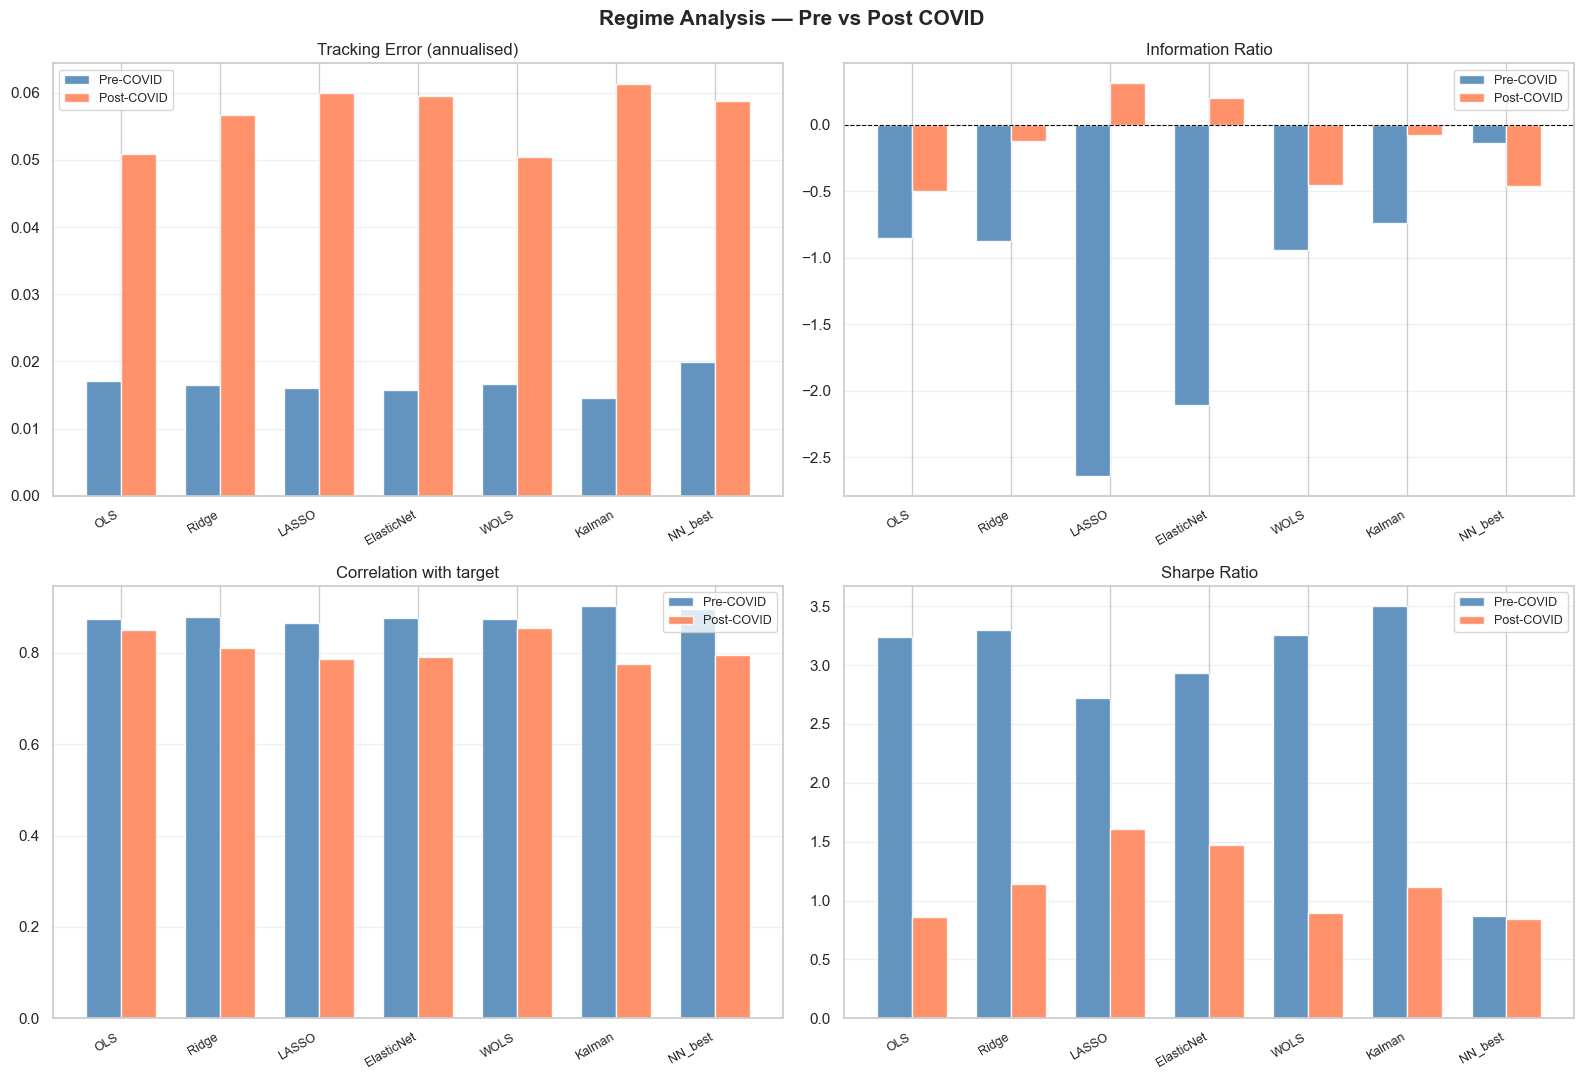

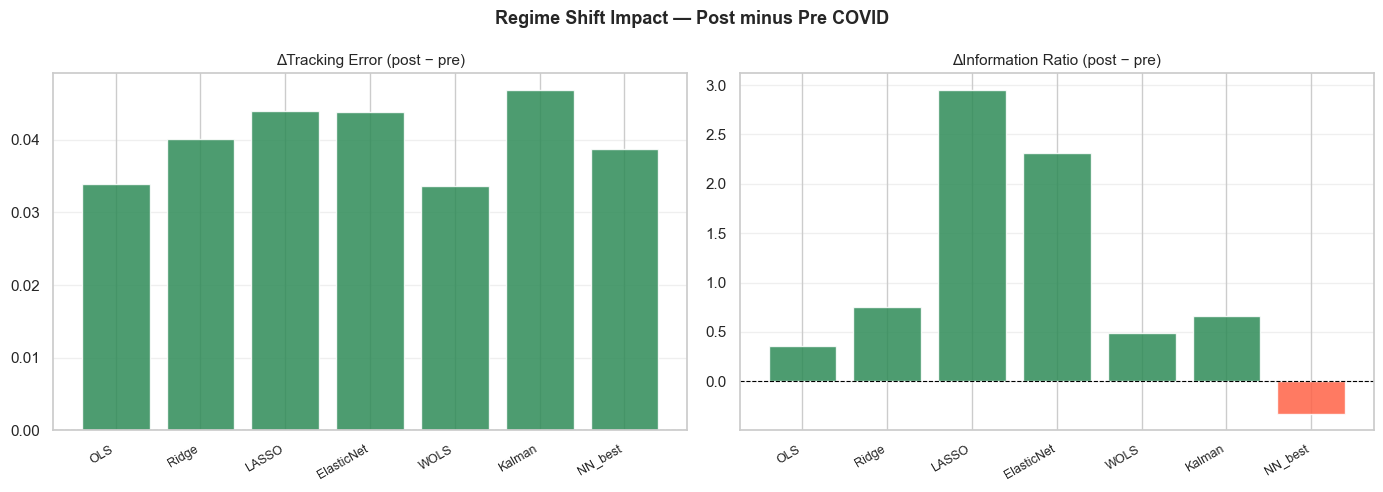

In [18]:
## Regime Analysis — Plots
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = [
    ("tracking_error",    "Tracking Error (annualised)",  False),
    ("information_ratio", "Information Ratio",             True),
    ("correlation",       "Correlation with target",       False),
    ("sharpe_replica",    "Sharpe Ratio",                  True),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Regime Analysis — Pre vs Post COVID", fontsize=15, fontweight="bold")

models = regime_df.index.get_level_values("model").unique()
x      = np.arange(len(models))
width  = 0.35

for ax, (metric, label, add_hline) in zip(axes.flatten(), metrics_to_plot):
    pre  = regime_df.xs("pre_covid",  level="regime")[metric].reindex(models)
    post = regime_df.xs("post_covid", level="regime")[metric].reindex(models)

    bars_pre  = ax.bar(x - width/2, pre,  width, label="Pre-COVID",  color="steelblue", alpha=0.85)
    bars_post = ax.bar(x + width/2, post, width, label="Post-COVID", color="coral",     alpha=0.85)

    if add_hline:
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_title(label, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# --- secondo plot: delta (post - pre) per evidenziare la degradazione ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Regime Shift Impact — Post minus Pre COVID", fontsize=13, fontweight="bold")

for ax, (metric, label, _) in zip(axes2, [
    ("tracking_error",    "ΔTracking Error (post − pre)",  False),
    ("information_ratio", "ΔInformation Ratio (post − pre)", True),
]):
    pre   = regime_df.xs("pre_covid",  level="regime")[metric].reindex(models)
    post  = regime_df.xs("post_covid", level="regime")[metric].reindex(models)
    delta = post - pre

    colors = ["seagreen" if v >= 0 else "tomato" for v in delta]
    ax.bar(x, delta, color=colors, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/regime_delta.png", dpi=150, bbox_inches="tight")
plt.show()

## Regime Analysis — Interpretation

### Tracking Error — degrades for all models, but unevenly

TE roughly triples or quadruples for every model moving from pre- to
post-COVID. This is expected: the March 2020 crash and the subsequent
volatility make replication intrinsically harder. The interesting signal
is *who degrades least*: **WOLS and OLS post the lowest post-COVID TE
(~0.050)**, suggesting that simpler, more stable weight structures are
more resilient when the regime shifts abruptly. Among linear models,
LASSO and ElasticNet suffer the most (~0.060 post-COVID), likely because
L1/L2 regularisation compresses weights in calm markets and then
under-responds when volatility spikes.

---

### Information Ratio — the most informative metric

Pre-COVID, every model posts a **negative IR**. This is expected in a
sustained bull market: during 2019–early 2020 the Monster Index ran a
positive trend that all models systematically underestimated, producing a
consistently negative active return. The magnitude of underestimation,
however, varies significantly across models: **LASSO (−2.64) and
ElasticNet (−2.11) show a much more negative pre-COVID IR than OLS,
Ridge, and WOLS (−0.85 to −0.94)**. This reflects the effect of
regularisation: L1/L2 shrinkage compresses the replica weights in calm
markets, causing the replica to undershoot a trending target by a wide
margin.

Post-COVID the picture partially reverses. **LASSO (+0.31) and
ElasticNet (+0.20) are the only two models with a positive IR in the
post-COVID period**. However, a positive IR in a replication context is
a **yellow flag, not a green one**. A replication strategy is designed
to *match* the target, not beat it — systematic outperformance suggests
either look-ahead bias, overfitting that leaked from the training period,
or simply sampling noise over a short window. With roughly 200 post-COVID
weekly observations, a positive mean active return may not be
statistically distinguishable from zero. The preferred model is therefore
the one with the lowest TE and IR closest to zero, not the highest IR.
This description fits **WOLS and OLS** better than LASSO or ElasticNet.

Kalman remains negative in both regimes, which is surprising given that
it is theoretically designed to track time-varying dynamics. The NN
posts the worst post-COVID IR (−0.56), likely because it learned
patterns specific to the training distribution that do not generalise
under stress.

---

### Correlation — stable across regimes

Correlation is the only metric that does not degrade materially in the
post-COVID period — every model stays above 0.77. **Kalman and NN lead
in the pre-COVID period (≥ 0.90)**, while **OLS and WOLS lead
post-COVID (≥ 0.85)**. The key takeaway is that all models correctly
track the *direction* of the Monster Index; the failure mode is in the
*magnitude*, not the sign.

---

### Sharpe Ratio — generalised collapse with one exception

The replica Sharpe ratio collapses post-COVID for nearly every model.
Among linear models, **LASSO (1.61) and ElasticNet (1.47) maintain the
highest post-COVID Sharpe**, while OLS (0.86) and WOLS (0.89) post the
weakest values. However, consistent with the IR discussion above, a high
Sharpe on the replica in isolation does not imply good replication
quality — it only means the replica itself had a favourable
return-to-risk profile in that subperiod, independently of how well it
tracked the target. Kalman achieves the highest pre-COVID Sharpe (3.50)
but falls sharply to 1.11 post-COVID — confirming that it adapts well in
calm markets but struggles with abrupt regime breaks. The NN posts the
weakest Sharpe values post-COVID, suggesting that the learned patterns
do not generalise under market stress.

---

### Bottom line

The most reliable metrics for evaluating a replication strategy are
**Tracking Error and Correlation**, not IR or Sharpe. On these two
metrics, **WOLS and OLS are the most robust models across regimes**:
they post the lowest post-COVID TE (~0.050) and maintain the highest
correlation in both subperiods (≥ 0.85 post-COVID). LASSO and
ElasticNet show apparent post-COVID strength in Sharpe and IR, but this
is driven by a favourable active return that is statistically fragile
and financially undesirable in a replication context. The additional
complexity of Kalman and the NN does not translate into regime
resilience — simpler, more stable weight structures outperform when the
market environment shifts abruptly.
